# Modelado Mínimos y Máximos BTC
---

### Configuración de ambiente

In [6]:
import yfinance as yf
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import pandas_ta as ta

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## Funciones
---

In [2]:
def obtener_datos_btc(fecha_inicio, fecha_fin):
    """Extrae datos de Yahoo Finance y calcula features básicas."""
    print(f"Descargando datos de BTC-USD desde {fecha_inicio}...")
    btc = yf.download("BTC-USD", start=fecha_inicio, end=fecha_fin)
    
    if isinstance(btc.columns, pd.MultiIndex):
        btc.columns = btc.columns.get_level_values(0)

    df = btc[['Open', 'High', 'Low', 'Close', 'Volume']].copy()
    df.dropna(inplace=True)
    
    # Feature básica: Retornos logarítmicos
    df['Retorno_Log'] = np.log(df['Close'] / df['Close'].shift(1))
    return df

def etiquetar_puntos_criticos(df, ventana):
    """
    Etiqueta máximos (1) y mínimos (-1) locales.
    Un punto es máximo/mínimo si es el extremo en +/- 'ventana' periodos.
    """
    # Creamos una copia para no alterar el original durante el cálculo
    temp_df = df.copy()
    
    # Buscamos el máximo y mínimo en la ventana centrada
    # center=True permite ver 'ventana' hacia atrás y 'ventana' hacia adelante
    temp_df['Max_Local'] = temp_df['High'].rolling(window=ventana*2+1, center=True).max()
    temp_df['Min_Local'] = temp_df['Low'].rolling(window=ventana*2+1, center=True).min()
    
    # Inicializamos la columna Target en 0 (Neutral)
    temp_df['Target'] = 0
    
    # Si el High actual es igual al Max_Local de la ventana, es un máximo (1)
    temp_df.loc[temp_df['High'] == temp_df['Max_Local'], 'Target'] = 1
    
    # Si el Low actual es igual al Min_Local de la ventana, es un mínimo (-1)
    temp_df.loc[temp_df['Low'] == temp_df['Min_Local'], 'Target'] = -1
    
    # Limpiamos columnas auxiliares
    temp_df.drop(columns=['Max_Local', 'Min_Local'], inplace=True)
    
    return temp_df

def agregar_indicadores_avanzados(
    df,
    rsi_len=14,
    bb_len=20,
    stoch_k=9, stoch_d=6,
    stochrsi_len=14,
    macd_fast=12, macd_slow=26, macd_sig=9,
    adx_len=14,
    willr_len=14,
    cci_len=14,
    atr_len=14,
    roc_len=10,
    eri_len=13,
    uo_fast=7, uo_med=14, uo_slow=28,
    vol_ma_len=20 # Media móvil para nuestro volumen relativo
):
    """
    Calcula indicadores técnicos avanzados usando pandas_ta.
    Todos los periodos son parametrizables para facilitar optimizaciones futuras.
    """
    temp_df = df.copy()
    
    # Aseguramos que el índice sea datetime
    if not isinstance(temp_df.index, pd.DatetimeIndex):
         temp_df.index = pd.to_datetime(temp_df.index)

    # 1. RSI
    temp_df.ta.rsi(length=rsi_len, append=True)
    
    # 2. Bandas de Bollinger
    temp_df.ta.bbands(length=bb_len, append=True)
    
    # Retornos y Volumen Relativo manuales
    temp_df['Retorno_1d'] = temp_df['Close'].pct_change()
    temp_df['Volumen_Relativo'] = temp_df['Volume'] / temp_df['Volume'].rolling(window=vol_ma_len).mean()
    
    # 3. STOCH
    temp_df.ta.stoch(k=stoch_k, d=stoch_d, append=True)
    
    # 4. STOCHRSI
    temp_df.ta.stochrsi(length=stochrsi_len, append=True)
    
    # 5. MACD (Añadí macd_sig=9 porque pandas_ta lo usa por defecto para el histograma)
    temp_df.ta.macd(fast=macd_fast, slow=macd_slow, signal=macd_sig, append=True)
    
    # 6. ADX
    temp_df.ta.adx(length=adx_len, append=True)
    
    # 7. Williams %R
    temp_df.ta.willr(length=willr_len, append=True)
    
    # 8. CCI
    temp_df.ta.cci(length=cci_len, append=True)
    
    # 9. ATR
    temp_df.ta.atr(length=atr_len, append=True)
    
    # 10. ROC
    temp_df.ta.roc(length=roc_len, append=True)
    
    # 11. Bull/Bear Power (Elder-Ray Index)
    temp_df.ta.eri(length=eri_len, append=True)
    
    # 12. Ultimate Oscillator
    temp_df.ta.uo(fast=uo_fast, medium=uo_med, slow=uo_slow, append=True)
    
    # Limpiamos las filas iniciales que quedan con NaN por los periodos de cálculo
    temp_df.dropna(inplace=True)
    
    return temp_df

def agregar_contexto_macro(df_btc):
    """
    Descarga datos del S&P 500, DXY y Oro, y los alinea con el dataset de Bitcoin,
    manejando los cierres de mercado de fin de semana.
    """
    print("Iniciando descarga de datos macroeconómicos...")
    temp_df = df_btc.copy()
    
    # Extraemos las fechas de nuestro dataset actual para descargar exactamente el mismo periodo
    fecha_inicio = temp_df.index.min()
    # Sumamos un día a la fecha final para asegurar que yfinance incluya el último día
    fecha_fin = temp_df.index.max() + pd.Timedelta(days=1) 
    
    # Diccionario con los nombres y sus tickers en Yahoo Finance
    activos_macro = {
        "SP500": "^GSPC", 
        "DXY": "DX-Y.NYB", 
        "Oro": "GC=F"
    }
    
    # Creamos un DataFrame vacío pero con las mismas fechas que Bitcoin (los 365 días del año)
    df_macro = pd.DataFrame(index=temp_df.index)
    
    for nombre, ticker in activos_macro.items():
        print(f"-> Descargando {nombre} ({ticker})...")
        data = yf.download(ticker, start=fecha_inicio, end=fecha_fin, progress=False)
        
        # Limpieza del MultiIndex de yfinance (como hicimos con BTC)
        if isinstance(data.columns, pd.MultiIndex):
            data.columns = data.columns.get_level_values(0)
            
        # Guardamos solo el precio de cierre
        df_macro[f'{nombre}_Close'] = data['Close']
    
    # --- EL TRUCO DEL FIN DE SEMANA (Forward Fill) ---
    # Rellenamos los NaN de los fines de semana con el último dato válido (Viernes)
    df_macro = df_macro.ffill()
    
    # Rellenamos hacia atrás (Back Fill) por si el día 1 del dataset fue fin de semana
    df_macro = df_macro.bfill()
    
    # Calculamos los retornos diarios de los activos macro (Esto le sirve más al modelo que el precio crudo)
    for nombre in activos_macro.keys():
        df_macro[f'{nombre}_Retorno'] = df_macro[f'{nombre}_Close'].pct_change()
        
    # Unimos la macroeconomía a nuestro dataset del Proyecto Apex
    # Como ambos comparten el mismo índice (fechas), la unión es perfecta
    temp_df = temp_df.join(df_macro)
    
    # Eliminamos la primera fila que quedará con NaN por calcular los retornos
    temp_df.dropna(inplace=True)
    
    print("\n¡Contexto macro agregado exitosamente!")
    return temp_df


## Carga de datos
---


In [9]:
# --- EJECUCIÓN DEL PROYECTO APEX ---

# 1. Definimos parámetros
VENTANA_T = 5  # Esto buscará el máximo/mínimo en un rango de 7 velas (3 atrás, la actual, 3 adelante)

# 2. Obtenemos datos
df_apex = obtener_datos_btc(fecha_inicio="2024-01-01", fecha_fin="2026-01-01")

# 3. Aplicamos el etiquetado con la ventana parametrizada
df_apex = etiquetar_puntos_criticos(df_apex, ventana=VENTANA_T)

# 4. Resultados
print(f"\nEtiquetado completado con ventana t={VENTANA_T}")
print(df_apex['Target'].value_counts(dropna=False, normalize=True)) # Ver cuántos puntos encontramos
print("\nMuestra de puntos detectados (Target != 0):")
print(df_apex[df_apex['Target'] != 0].head(10))

[*********************100%***********************]  1 of 1 completed

Descargando datos de BTC-USD desde 2024-01-01...

Etiquetado completado con ventana t=5
Target
 0    0.874145
 1    0.062927
-1    0.062927
Name: proportion, dtype: float64

Muestra de puntos detectados (Target != 0):
Price               Open          High           Low         Close  \
Date                                                                 
2024-01-11  46656.074219  48969.371094  45678.644531  46368.585938   
2024-01-23  39518.714844  40127.351562  38521.894531  39845.550781   
2024-01-30  43300.226562  43838.945312  42711.371094  42952.609375   
2024-02-20  51777.726562  52945.050781  50792.312500  52284.875000   
2024-02-23  51283.906250  51497.933594  50561.777344  50731.949219   
2024-03-05  68341.054688  69170.625000  59323.910156  63801.199219   
2024-03-14  73079.375000  73750.070312  68563.023438  71396.593750   
2024-03-20  61930.156250  68115.257812  60807.785156  67913.671875   
2024-03-27  69991.898438  71727.687500  68381.929688  69455.343750   
2024-04-03  

## Indicadores técnicos (features)
---

In [10]:
# Aplicamos la función a nuestro dataset
# (Asumiendo que 'df_apex' ya tiene la columna 'Target' del paso anterior)
df_apex = agregar_indicadores_avanzados(df_apex)
print("Features agregadas con éxito. Tamaño del dataset:", df_apex.shape)

Features agregadas con éxito. Tamaño del dataset: (698, 34)


## Variables macroeconómicas
---

In [11]:
# --- EJECUCIÓN ---
# Aplicamos la función a nuestro dataset que ya tiene los indicadores técnicos
df_apex = agregar_contexto_macro(df_apex)

# Revisamos las nuevas columnas
nuevas_columnas = [col for col in df_apex.columns if 'SP500' in col or 'DXY' in col or 'Oro' in col]
print("\nNuevas variables macro disponibles para el modelo:")
print(nuevas_columnas)

Iniciando descarga de datos macroeconómicos...
-> Descargando SP500 (^GSPC)...
-> Descargando DXY (DX-Y.NYB)...
-> Descargando Oro (GC=F)...

¡Contexto macro agregado exitosamente!

Nuevas variables macro disponibles para el modelo:
['SP500_Close', 'DXY_Close', 'Oro_Close', 'SP500_Retorno', 'DXY_Retorno', 'Oro_Retorno']


## Entrenamiento del modelo Random Forest (con variables macro)
---

Entrenando con 30 variables (Técnicas + Macro)...
Días de entrenamiento: 557 | Días de prueba: 140

Entrenando nuevo modelo Random Forest...

--- NUEVO REPORTE DE CLASIFICACIÓN (Con Macro) ---
              precision    recall  f1-score   support

          -1       0.00      0.00      0.00         8
           0       0.89      1.00      0.94       124
           1       0.00      0.00      0.00         8

    accuracy                           0.89       140
   macro avg       0.30      0.33      0.31       140
weighted avg       0.78      0.89      0.83       140



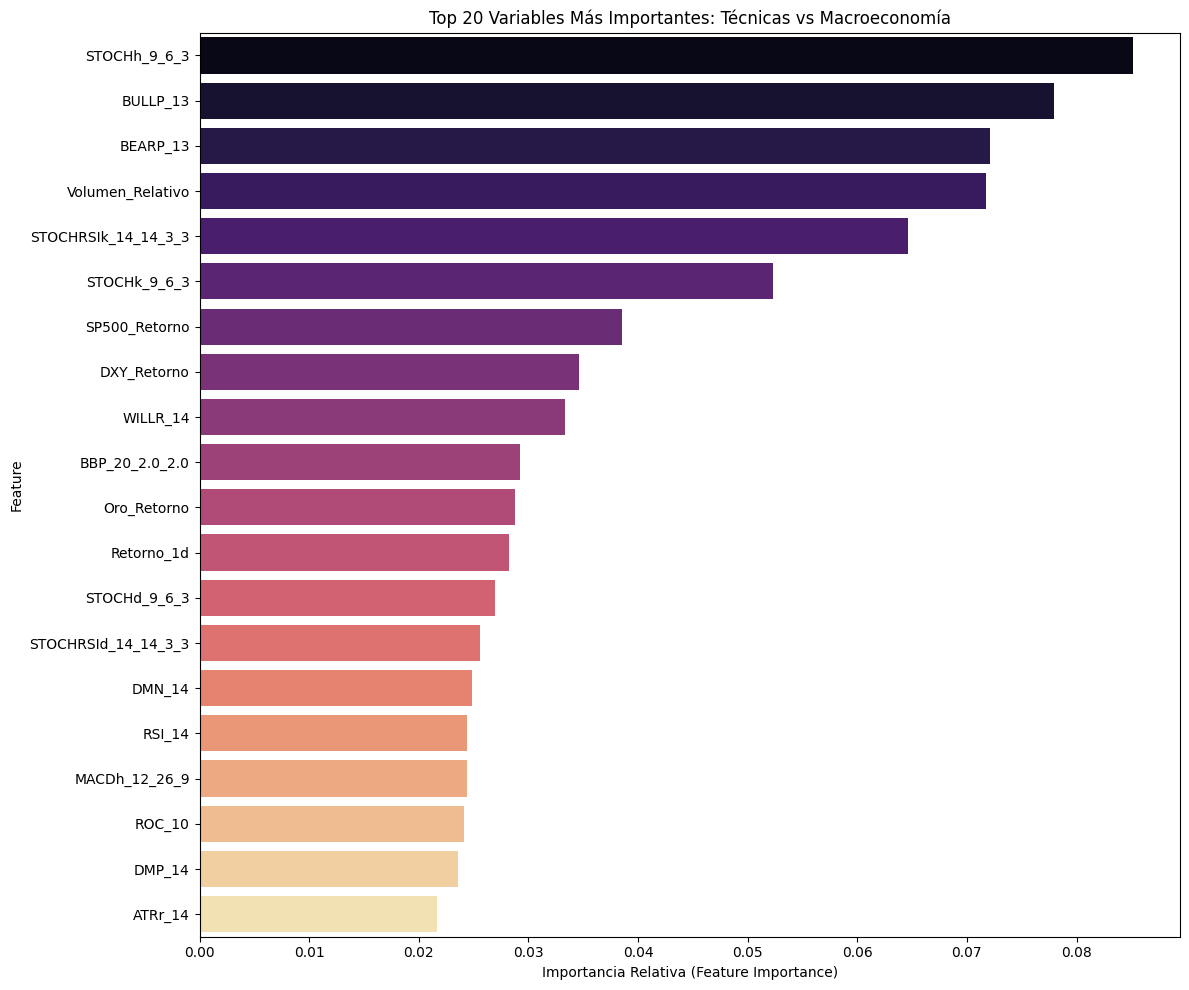

In [12]:
# --- 1. CONFIGURACIÓN DE FEATURES ---
# Excluimos los precios crudos de BTC, el Target y los precios crudos macroeconómicos
columnas_excluir = [
    'Open', 'High', 'Low', 'Close', 'Volume', 'Target',
    'SP500_Close', 'DXY_Close', 'Oro_Close' # ¡Importante! Solo queremos sus retornos
    , 'Retorno_Log'
]

# Creamos la lista final de features (X)
features = [col for col in df_apex.columns if col not in columnas_excluir]

# --- 2. PREPARACIÓN DE DATOS (Train / Test) ---
X = df_apex[features]
y = df_apex['Target']

# División cronológica (80% Train, 20% Test)
split_idx = int(len(df_apex) * 0.8)

X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

print(f"Entrenando con {len(features)} variables (Técnicas + Macro)...")
print(f"Días de entrenamiento: {len(X_train)} | Días de prueba: {len(X_test)}")

# --- 3. ENTRENAMIENTO DEL MODELO MACRO ---
modelo_rf_macro = RandomForestClassifier(
    n_estimators=100,
    random_state=42,
    class_weight='balanced',
    max_depth=10, 
    n_jobs=-1
)

print("\nEntrenando nuevo modelo Random Forest...")
modelo_rf_macro.fit(X_train, y_train)

# --- 4. EVALUACIÓN Y MÉTRICAS ---
y_pred_macro = modelo_rf_macro.predict(X_test)

print("\n--- NUEVO REPORTE DE CLASIFICACIÓN (Con Macro) ---")
print(classification_report(y_test, y_pred_macro))

# --- 5. IMPORTANCIA DE VARIABLES (TOP 20) ---
importancias = modelo_rf_macro.feature_importances_
df_importancias = pd.DataFrame({'Feature': features, 'Importancia': importancias})
df_importancias = df_importancias.sort_values(by='Importancia', ascending=False)

# Graficamos
plt.figure(figsize=(12, 10))
# Usamos una paleta diferente ('magma') para diferenciar de la gráfica anterior
sns.barplot(x='Importancia', y='Feature', data=df_importancias.head(20), palette='magma')
plt.title('Top 20 Variables Más Importantes: Técnicas vs Macroeconomía')
plt.xlabel('Importancia Relativa (Feature Importance)')
plt.ylabel('Feature')
plt.tight_layout() # Ajusta los márgenes para que los nombres largos se vean bien
plt.show()

In [13]:
print("Evaluando modelo con Ventana de 3 días y Umbrales Personalizados...\n")

# 1. Obtenemos las PROBABILIDADES en lugar de la predicción directa
# Esto devuelve un arreglo con 3 columnas: [Prob de -1, Prob de 0, Prob de 1]
probabilidades = modelo_rf_macro.predict_proba(X_test)

# 2. Definimos nuestro "Umbral de Valentía" (Threshold)
# Por defecto, el modelo exige > 50% para predecir un extremo.
# Vamos a bajarlo: si está al menos 25% seguro de que es un extremo, que nos avise.
UMBRAL_EXTREMO = 0.25

# Creamos un arreglo vacío para guardar nuestras nuevas predicciones "ajustadas"
y_pred_ajustado = np.zeros(len(y_test)) # Empezamos asumiendo que todo es 0 (Neutral)

# Obtenemos el mapeo de las clases del modelo para saber qué columna es cuál
clases = modelo_rf_macro.classes_
indice_minimo = np.where(clases == -1)[0][0]
indice_maximo = np.where(clases == 1)[0][0]

# 3. Aplicamos nuestra lógica personalizada
for i in range(len(probabilidades)):
    prob_minimo = probabilidades[i][indice_minimo]
    prob_maximo = probabilidades[i][indice_maximo]
    
    # Si la probabilidad de mínimo supera nuestro umbral
    if prob_minimo >= UMBRAL_EXTREMO:
        y_pred_ajustado[i] = -1
        
    # Si la probabilidad de máximo supera nuestro umbral
    # (Usamos elif suponiendo que no puede ser ambos a la vez con alta probabilidad)
    elif prob_maximo >= UMBRAL_EXTREMO:
        y_pred_ajustado[i] = 1

# --- EVALUACIÓN CON EL NUEVO UMBRAL ---
print(f"--- REPORTE DE CLASIFICACIÓN (Umbral: {UMBRAL_EXTREMO * 100}%) ---")
print(classification_report(y_test, y_pred_ajustado))

# Comparamos cuántas señales nos dio el modelo original vs el ajustado
predicciones_originales = modelo_rf_macro.predict(X_test)
print(f"\nSeñales detectadas con 50% de seguridad (Original): {np.sum(predicciones_originales != 0)}")
print(f"Señales detectadas con {UMBRAL_EXTREMO*100}% de seguridad (Ajustado): {np.sum(y_pred_ajustado != 0)}")

Evaluando modelo con Ventana de 3 días y Umbrales Personalizados...

--- REPORTE DE CLASIFICACIÓN (Umbral: 25.0%) ---
              precision    recall  f1-score   support

          -1       0.19      0.50      0.28         8
           0       0.91      0.85      0.88       124
           1       0.67      0.25      0.36         8

    accuracy                           0.80       140
   macro avg       0.59      0.53      0.51       140
weighted avg       0.86      0.80      0.82       140


Señales detectadas con 50% de seguridad (Original): 0
Señales detectadas con 25.0% de seguridad (Ajustado): 24


## Backtestester
---
Para este backtester, programaremos una lógica de operaciones en Spot.

La estrategia será:

- **Señal -1 (Mínimo)**: Compramos Bitcoin. Para no arriesgar la ruina total, invertiremos una fracción de nuestro capital por operación (ej. 10% del capital).

- **Señal 1 (Máximo)**: Vendemos la posición completa para asegurar ganancias.

- **Stop Loss (Gestión de Riesgo)**: Si el precio cae un cierto porcentaje desde nuestra compra, vendemos con pérdida para proteger el capital, sin esperar a que el modelo dé una señal de venta.

In [ ]:
# Función backtester
def backtest_apex(
        df_test, 
        predicciones, 
        capital_inicial=1000.0, 
        tamaño_posicion=0.10, 
        stop_loss=0.05):
    
    """
    Simula una estrategia de trading basada en las predicciones del modelo.
    capital_inicial: Capital base para arrancar (ej. 1000 USD).
    tamaño_posicion: Porcentaje del capital total a invertir en cada compra (ej. 10%).
    stop_loss: Porcentaje máximo de pérdida tolerada por operación (ej. 5%).
    """
    df_sim = df_test.copy()
    df_sim['Señal'] = predicciones
    
    capital_actual = capital_inicial
    posicion_abierta = False
    precio_compra = 0.0
    cantidad_btc = 0.0
    
    historial_trades = []
    evolucion_capital = []

    for fecha, fila in df_sim.iterrows():
        precio_actual = fila['Close']
        señal = fila['Señal']
        
        # Revisar Stop Loss si tenemos una posición abierta
        if posicion_abierta:
            caida_desde_compra = (precio_actual - precio_compra) / precio_compra
            if caida_desde_compra <= -stop_loss:
                # Se ejecutó el Stop Loss
                capital_actual += cantidad_btc * precio_actual
                historial_trades.append({'Fecha': fecha, 'Tipo': 'Venta (Stop Loss)', 'Precio': precio_actual, 'Capital': capital_actual})
                posicion_abierta = False
                cantidad_btc = 0.0

        # Lógica de Compra
        if señal == -1 and not posicion_abierta:
            monto_invertir = capital_actual * tamaño_posicion
            cantidad_btc = monto_invertir / precio_actual
            capital_actual -= monto_invertir
            precio_compra = precio_actual
            posicion_abierta = True
            historial_trades.append(
                {
                    'Fecha': fecha, 
                    'Tipo': 'Compra', 
                    'Precio': precio_actual, 
                    'Capital': capital_actual + (cantidad_btc * precio_actual)
                    })
            
        # Lógica de Venta (Toma de Ganancias)
        elif señal == 1 and posicion_abierta:
            capital_actual += cantidad_btc * precio_actual
            historial_trades.append(
                {
                    'Fecha': fecha, 
                    'Tipo': 'Venta (Take Profit)', 
                    'Precio': precio_actual, 
                    'Capital': capital_actual
                    })
            posicion_abierta = False
            cantidad_btc = 0.0
            
        # Registrar el valor total del portafolio (Efectivo + Valor en BTC)
        valor_portafolio = capital_actual + (cantidad_btc * precio_actual if posicion_abierta else 0)
        evolucion_capital.append(valor_portafolio)

    df_sim['Valor_Portafolio'] = evolucion_capital
    
    # Calcular métricas finales
    retorno_total = ((df_sim['Valor_Portafolio'].iloc[-1] - capital_inicial) / capital_inicial) * 100
    trades_df = pd.DataFrame(historial_trades)
    
    print(f"--- RESULTADOS DEL BACKTEST ---")
    print(f"Capital Inicial: ${capital_inicial:.2f} USD")
    print(f"Capital Final: ${df_sim['Valor_Portafolio'].iloc[-1]:.2f} USD")
    print(f"Retorno Total: {retorno_total:.2f}%")
    print(f"Total de operaciones cerradas: {len(trades_df[trades_df['Tipo'].str.contains('Venta')]) if not trades_df.empty else 0}")
    
    # Gráfica de la evolución del capital
    plt.figure(figsize=(10, 5))
    plt.plot(df_sim.index, df_sim['Valor_Portafolio'], color='blue', label='Curva de Capital')
    plt.title('Evolución del Portafolio de Trading')
    plt.ylabel('Valor en USD')
    plt.xlabel('Fecha')
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()
    
    return df_sim, trades_df

Simulación

In [17]:
# 1. Recuperamos la porción de "Test" pero del DataFrame original (que SÍ tiene 'Close')
split_idx = int(len(df_apex) * 0.8)
df_test_completo = df_apex.iloc[split_idx:].copy()


In [18]:
# 2. Nos aseguramos de que las predicciones ajustadas y el DataFrame tengan la misma longitud
assert len(df_test_completo) == len(y_pred_ajustado), "Error: Las longitudes no coinciden"

--- RESULTADOS DEL BACKTEST ---
Capital Inicial: $1000.00 USD
Capital Final: $985.08 USD
Retorno Total: -1.49%
Total de operaciones cerradas: 5


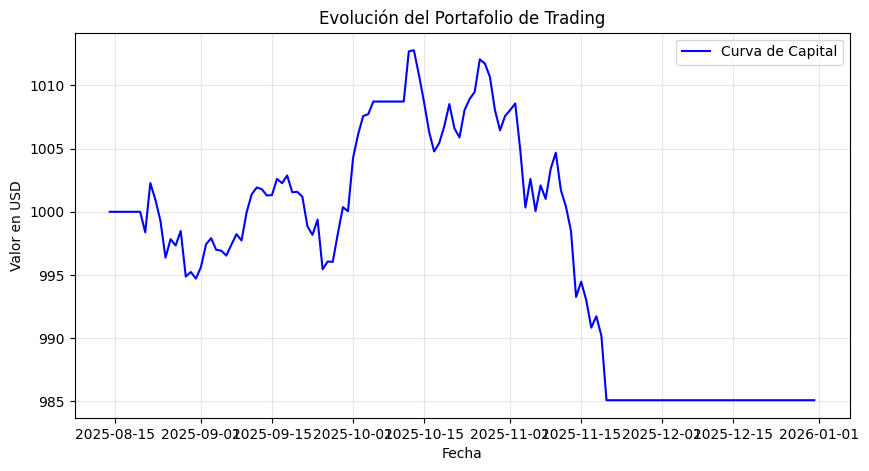

In [19]:
# 3. ¡Ahora sí ejecutamos el backtester!
# Le pasamos los datos completos y las predicciones que generamos con el Random Forest
df_simulacion, trades_rf = backtest_apex(df_test_completo, y_pred_ajustado)

In [20]:
# Opcional: ver las primeras 5 operaciones que hizo el bot
if not trades_rf.empty:
    print("\nÚltimas operaciones del bot:")
    print(trades_rf.tail())


Últimas operaciones del bot:
       Fecha               Tipo         Precio      Capital
5 2025-11-04  Venta (Stop Loss)  101590.523438  1000.337110
6 2025-11-04             Compra  101590.523438  1000.337110
7 2025-11-14  Venta (Stop Loss)   94397.789062   993.254599
8 2025-11-14             Compra   94397.789062   993.254599
9 2025-11-20  Venta (Stop Loss)   86631.898438   985.083321


### Análisis forense de tu gráfica:

1. **El pico de esperanza (Octubre):** La curva subió por encima de los 1010 USD. El modelo identificó correctamente algunos movimientos y el capital creció. Por lo tanto, el sistema es capaz de generar ganancias.

2. **El rescate del Stop Loss (Noviembre):** Esa caída pronunciada es donde el mercado se fue en contra de la compra. Pero aquí funcionó la gestión de riesgo: el Stop Loss cortó la hemorragia, asumiendo una pérdida controlada en lugar de dejar que la cuenta se hundiera.

3. **La "hibernación" (Línea plana de Dic a Ene):** Esta es la parte más fascinante. Tras la caída, la línea se vuelve completamente horizontal. ¿Qué significa? Que el modelo analizó la volatilidad y los indicadores macro, no vió ninguna probabilidad mayor al 25% de que hubiera un mínimo seguro, y decidió **quedarse en efectivo**. En el trading, proteger el capital sin operar es una de las habilidades más difíciles de aprender.

El modelo fue conservador y protegió el capital.